/home/kianmilani/Projects/scoob-llowfsc/scoob_llowfsc
/home/kianmilani/Projects/scoob-llowfsc/scoob_llowfsc


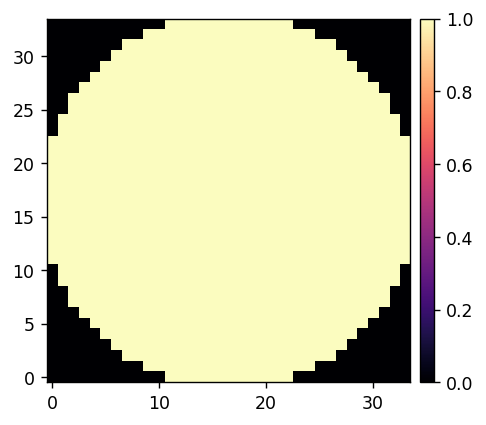

In [45]:
import numpy as np
import astropy.units as u
from astropy.io import fits
import time 
from importlib import reload
import copy
from datetime import datetime
today = int(datetime.today().strftime('%Y%m%d'))

import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm, Normalize, CenteredNorm
from matplotlib.patches import Circle, Rectangle

import scoob_llowfsc
print(scoob_llowfsc.path)
data_path = scoob_llowfsc.path/'exp-data'

from magpyx.utils import ImageStream
import purepyindi
from purepyindi import INDIClient
import purepyindi2
from purepyindi2 import IndiClient
client0 = INDIClient('localhost', 7624)
client0.start()
client = IndiClient()
client.connect()
client.get_properties()

import os
from pathlib import Path

import scoob_llowfsc
from scoob_llowfsc.math_module import xp, xcipy, ensure_np_array
from scoob_llowfsc import utils
from scoob_llowfsc import dm
from scoob_llowfsc import telem
import scoob_llowfsc.scoob_interface as scoobi
print(scoob_llowfsc.path)
data_path = scoob_llowfsc.path/'exp-data'

camsci_path = Path('/opt/MagAOX/rawimages/camsci/')
camlo_path = Path('/opt/MagAOX/rawimages/camlo/')
dm01_path = Path('/opt/MagAOX/rawimages/dm00disp01/')
dm02_path = Path('/opt/MagAOX/rawimages/dm00disp02/')
dm03_path = Path('/opt/MagAOX/rawimages/dm00disp03/')

dm00_stream = ImageStream('dm00disp00')
dm01_stream = ImageStream('dm00disp01')
dm02_stream = ImageStream('dm00disp02')
dm03_stream = ImageStream('dm00disp03')

wavelength_c = 633e-9
camsci_pxscl = 4.6e-6
camsci_pxscl_lamDc = 0.307

from scoob_llowfsc import dm
dm_mask = ensure_np_array(dm.make_mask(34))
utils.imshow([dm_mask])


In [24]:
exp_path = data_path/f'exp-{today}'
telem_data_path = data_path/f'exp-{today}'/'raw-telem'
unpacked_data_path = data_path/f'exp-{today}'/'unpacked-telem'
telem.make_dir(exp_path)
telem.make_dir(telem_data_path)
telem.make_dir(unpacked_data_path)

Directory '/home/kianmilani/Projects/scoob-llowfsc/scoob_llowfsc/exp-data/exp-20250409' already exists.
Directory '/home/kianmilani/Projects/scoob-llowfsc/scoob_llowfsc/exp-data/exp-20250409/raw-telem' already exists.
Directory '/home/kianmilani/Projects/scoob-llowfsc/scoob_llowfsc/exp-data/exp-20250409/unpacked-telem' created successfully.


In [46]:
xc, yc = (5450, 1100) # 1005, 1125
npsf = 256
scoobi.set_cam_roi(xc, yc, npsf, client0, cam_name='camsci', bin_mode=2)

scoobi.set_cam_exp_time(0.01, client0, cam_name='camsci',)
scoobi.set_cam_gain(120, client0, cam_name='camsci',)
scoobi.set_cam_blacklevel(1, client0, cam_name='camsci',)

Set camsci ROI.
Set the camsci exposure time to 1.00e-02s
Set the camsci gain setting to 120.0
Set the camsci blacklevel to 1.0


In [47]:
reload(scoobi)
xc, yc = (3900, 2575)
npsf = 256
scoobi.set_cam_roi(xc, yc, npsf, client0, cam_name='camlo', bin_mode=2)
scoobi.set_cam_exp_time(0.001, client0, cam_name='camlo',)
scoobi.set_cam_gain(120, client0, cam_name='camlo',)
scoobi.set_cam_blacklevel(2, client0, cam_name='camlo',)

Set camlo ROI.
Set the camlo exposure time to 1.00e-03s
Set the camlo gain setting to 120.0
Set the camlo blacklevel to 2.0


In [ ]:
reload(telem)
telem.delete_files(camsci_path/'*.xrif')
telem.delete_files(camlo_path/'*.xrif')

In [36]:
reload(telem)
telem.toggle(1, 'camsci', client0)
time.sleep(1)
telem.toggle(0, 'camsci', client0)

In [37]:
# telem.move_files(camlo_path, telem_data_path)
telem.move_files(camsci_path, telem_data_path)

In [38]:
telem.unpack_data(telem_data_path, unpacked_data_path)

In [23]:
telem.delete_files(unpacked_data_path)

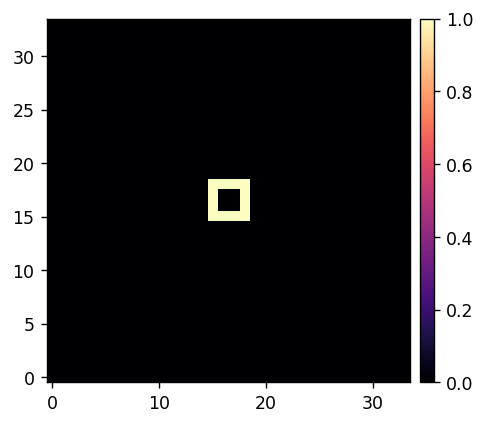

In [42]:
dm_command = ensure_np_array(dm.make_ring(rad=2))
utils.imshow([dm_command])

# Test DM shmimWriter

In [64]:
reload(telem)
dm_channel = 'dm00disp02'
telem.toggle(1, dm_channel, client0)

for i in range(10):
    time.sleep(1)
    dm02_stream.write( 0.010 * ensure_np_array(dm.make_ring(rad=2+i)) )

time.sleep(1)
dm02_stream.write( np.zeros((34,34)) )

telem.toggle(0, dm_channel, client0)

In [65]:
# telem.move_files(camlo_path, telem_data_path)
telem.move_files(dm02_path, telem_data_path)

In [66]:
telem.unpack_data(telem_data_path, unpacked_data_path)

In [67]:
dm_fnames = telem.get_fnames(unpacked_data_path/f'{dm_channel}*')
dm_fnames

['/home/kianmilani/Projects/scoob-llowfsc/scoob_llowfsc/exp-data/exp-20250409/unpacked-telem/dm00disp02_20250409225454367279115.fits',
 '/home/kianmilani/Projects/scoob-llowfsc/scoob_llowfsc/exp-data/exp-20250409/unpacked-telem/dm00disp02_20250409225455370294657.fits',
 '/home/kianmilani/Projects/scoob-llowfsc/scoob_llowfsc/exp-data/exp-20250409/unpacked-telem/dm00disp02_20250409225456374320953.fits',
 '/home/kianmilani/Projects/scoob-llowfsc/scoob_llowfsc/exp-data/exp-20250409/unpacked-telem/dm00disp02_20250409225457377623572.fits',
 '/home/kianmilani/Projects/scoob-llowfsc/scoob_llowfsc/exp-data/exp-20250409/unpacked-telem/dm00disp02_20250409225458381018071.fits',
 '/home/kianmilani/Projects/scoob-llowfsc/scoob_llowfsc/exp-data/exp-20250409/unpacked-telem/dm00disp02_20250409225459383158156.fits',
 '/home/kianmilani/Projects/scoob-llowfsc/scoob_llowfsc/exp-data/exp-20250409/unpacked-telem/dm00disp02_20250409225500387693315.fits',
 '/home/kianmilani/Projects/scoob-llowfsc/scoob_llowfsc

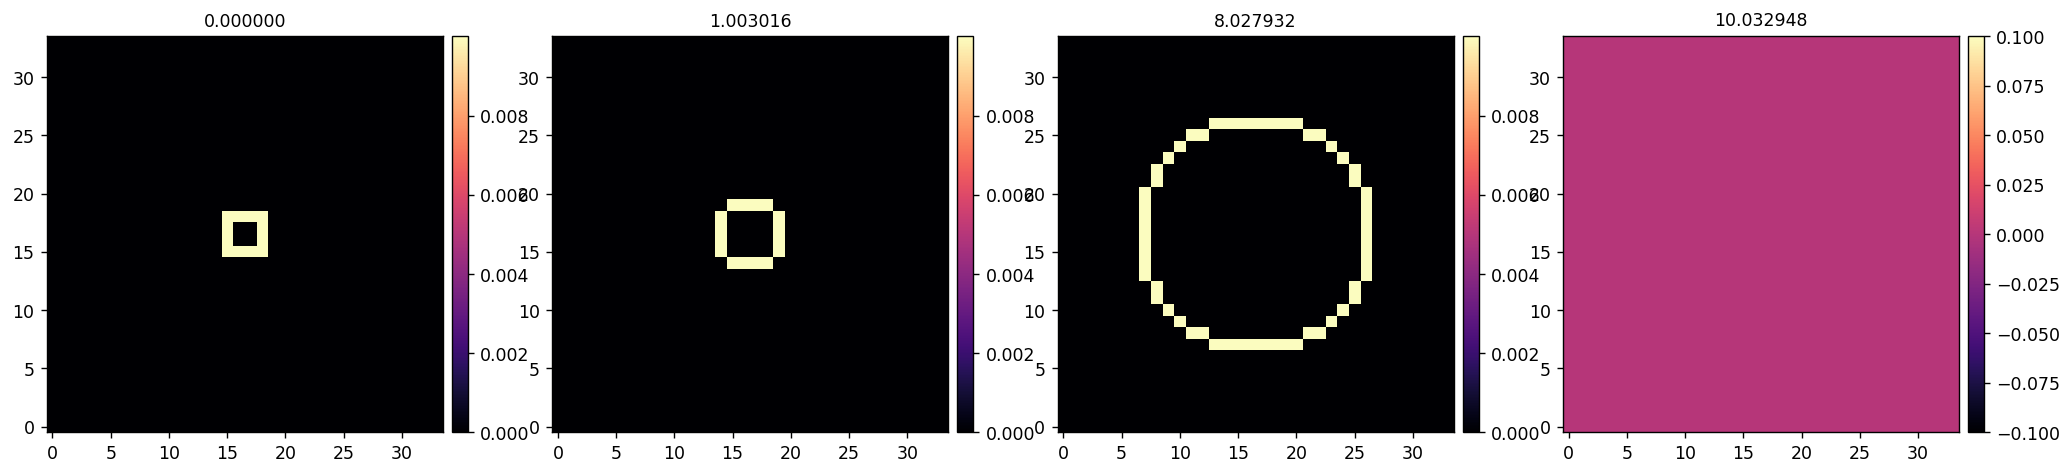

In [68]:
reload(telem)
data, data_times = telem.read_telem_data(dm_fnames, absolute=False)
utils.imshow(
    [data[0], data[1], data[-2], data[-1]],
    titles=[f'{data_times[0]:.6f}',
            f'{data_times[1]:.6f}',
            f'{data_times[-2]:.6f}',
            f'{data_times[-1]:.6f}'],
    figsize=(20,5),
)